Index(['Unnamed: 0', 'MagpieData minimum Number', 'MagpieData maximum Number',
       'MagpieData range Number', 'MagpieData mean Number',
       'MagpieData avg_dev Number', 'MagpieData mode Number',
       'MagpieData minimum MendeleevNumber',
       'MagpieData maximum MendeleevNumber',
       'MagpieData range MendeleevNumber',
       ...
       'avg d valence electrons', 'avg f valence electrons',
       'frac s valence electrons', 'frac p valence electrons',
       'frac d valence electrons', 'frac f valence electrons', 'Grain Size',
       'Calculated Solid Solution', 'Calculated Grain Boundary',
       'Calculated Yield Strength'],
      dtype='object', length=280)
0       72.0
1       84.0
2       86.0
3      284.0
4      316.0
       ...  
854    116.0
855    140.0
856     85.0
857    121.0
858    156.0
Name: 屈服强度, Length: 859, dtype: float64


Index(['MagpieData minimum Number', 'MagpieData maximum Number',
       'MagpieData range Number', 'MagpieData mean Number',
       'MagpieData avg_dev Number', 'MagpieData mode Number',
       'MagpieData minimum MendeleevNumber',
       'MagpieData maximum MendeleevNumber',
       'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber',
       ...
       'avg d valence electrons', 'avg f valence electrons',
       'frac s valence electrons', 'frac p valence electrons',
       'frac d valence electrons', 'frac f valence electrons', 'Grain Size',
       'Calculated Solid Solution', 'Calculated Grain Boundary',
       'Calculated Yield Strength'],
      dtype='object', length=279)


[17:37:00] WARNING: C:\b\abs_0fh_d4x2ng\croot\xgboost-split_1713973188995\work\cpp_src\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[17:37:02] WARNING: C:\b\abs_0fh_d4x2ng\croot\xgboost-split_1713973188995\work\cpp_src\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[17:37:04] WARNING: C:\b\abs_0fh_d4x2ng\croot\xgboost-split_1713973188995\work\cpp_src\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[17:37:06] WARNING: C:\b\abs_0fh_d4x2ng\croot\xgboost-split_1713973188995\work\cpp_src\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will d

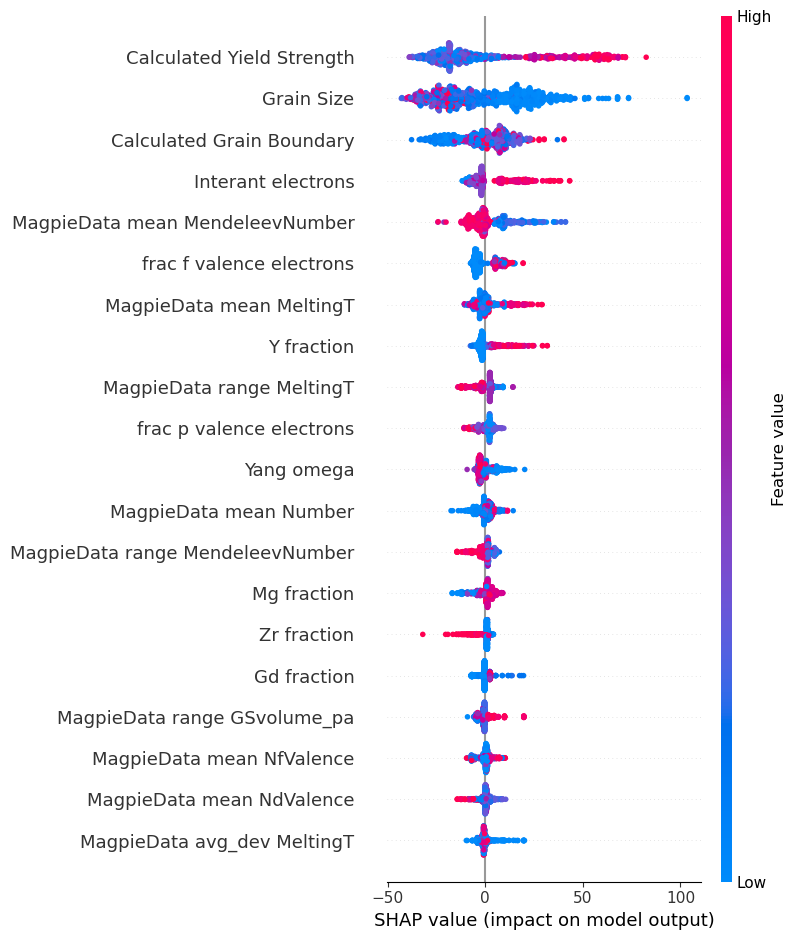

<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import joblib
import shap
import pandas as pd
import xgboost as xgb
# 读取数据
df = pd.read_excel('Without_habitplane.xlsx',index_col=0)

# 划分特征和目标变量
X = df.iloc[:, :-3]
y = df['屈服强度']
print(X.columns)
# 初始化五折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 保存每一折模型和SHAP结果
fold_models = []
fold_shap_values = []
X_fold = pd.DataFrame()
# 进行五折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    X_fold =pd.concat([X_fold,X_train])
    model = xgb.XGBRegressor()
    model.fit(X_train, y_train)
    
    # 保存模型
    joblib.dump(model, f'xgb_model_fold_{fold}.pkl')
    
    # 记录模型
    fold_models.append(model)
    
    # 计算SHAP值
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_train)
    
    # 记录SHAP值
    fold_shap_values.append(shap_values)

# 初始化空的数据框
combined_shap = pd.DataFrame()

# 合并SHAP值
for fold, shap_values in enumerate(fold_shap_values):
    shap_df = pd.DataFrame(shap_values.values, columns=X.columns)
    shap_df['fold'] = fold
    combined_shap = pd.concat([combined_shap, shap_df], axis=0)

# 保存特征值和SHAP值到Excel
with pd.ExcelWriter('xgb_shap_results.xlsx') as writer:
    X_fold.to_excel(writer, sheet_name='Original Features', index=False)
    combined_shap.to_excel(writer, sheet_name='SHAP Values', index=False)
import matplotlib.pyplot as plt

# 选择一个模型进行可视化
model = fold_models[0]  # 使用第一个模型进行示例
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# 创建SHAP summary plot
shap.summary_plot(shap_values, X)
plt.savefig('shap_summary_plot.png')
